# Website User Behaviour & Conversion Analysis

**Analyst:** Vu Thuan Huynh  
**Period:** October 2024 – March 2025  
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn) · SQL · Tableau  
**Dataset:** 9,835 sessions · 658 orders · AUD $110,892 revenue  

---

## 📋 Project Overview

Thrive Education is a Melbourne-based tutoring platform offering one-on-one sessions across VCE/HSC subjects. 
This analysis examines 6 months of website activity to:

1. Understand traffic patterns and channel performance
2. Map the full conversion funnel and identify drop-off points
3. Measure the impact of a pricing page redesign (A/B test)
4. Segment users by subject, device, and behaviour
5. Track trial-to-paid upgrade journeys (cohort analysis)

**Note:** Data has been anonymised and synthetic values used to protect user privacy.

---
> ## ⚠️ Data Disclaimer
>
> **The data used in this project is entirely synthetic and self-generated — it does not represent any real company, customer, or transaction.**
>
> During my time working with Thrive Education, I observed the structure of the internal analytics data (table schemas, column names, data types, and general business logic). However, due to **privacy and confidentiality obligations**, I was unable to use or export any real company data.
>
> To build this portfolio project, I recreated a dataset that **mirrors the same structure and format** as the real data — including the same tables (`sessions`, `orders`, `funnel_events`, `cohort_upgrades`), the same column names, and realistic value distributions — but **all values, user IDs, dates, and figures are entirely made up**.
>
> This approach was reviewed and **approved by my employer**, who confirmed that showcasing analytical methodology using synthetic data of equivalent structure is acceptable for portfolio purposes.
>
> *The analysis techniques, business logic, and insights demonstrated here reflect real analytical work, applied to simulated data.*

---

## 1. Setup & Data Loading

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, math
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='white')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False})
NAVY, BLUE, TEAL, ORANGE, GREEN, RED, GRAY = '#1B2A4A','#2563A8','#0D9488','#EA580C','#16A34A','#DC2626','#6B7280'

PURPLE = '#7C3AED'
palette = [BLUE, TEAL, ORANGE, PURPLE, GREEN, RED]


In [2]:
# Load datasets
sessions = pd.read_csv('sessions.csv', parse_dates=['date'])
orders   = pd.read_csv('orders.csv',   parse_dates=['date'])
funnel   = pd.read_csv('funnel_events.csv', parse_dates=['date'])
cohort   = pd.read_csv('cohort_upgrades.csv')

print(f'Sessions : {len(sessions):,} rows')
print(f'Orders   : {len(orders):,} rows')
print(f'Funnel   : {len(funnel):,} rows')
print(f'Cohort   : {len(cohort):,} rows')
sessions.head(3)

Sessions : 9,835 rows
Orders   : 658 rows
Funnel   : 59,010 rows
Cohort   : 104 rows


,session_id,user_id,date,month,week,source,device,landing_page,pages_viewed,session_duration_sec,bounced,is_new_user,ab_group,converted
0,S00001,U0001,2024-10-01,2024-10,2024-W40,Email,Mobile,/pricing,2,150,0,1,NaN,0
1,S00002,U0001,2024-10-01,2024-10,2024-W40,Organic,Tablet,/,2,150,0,0,NaN,0
2,S00003,U0001,2024-10-01,2024-10,2024-W40,Organic,Desktop,/services,2,45,0,0,NaN,0


## 2. Executive KPI Summary

Before diving into breakdowns, let's establish the top-line metrics across the full 6-month period.

In [3]:
total_sessions  = len(sessions)
total_orders    = len(orders)
total_revenue   = orders['price'].sum()
overall_cvr     = total_orders / total_sessions * 100
avg_order_value = orders['price'].mean()
unique_users    = sessions['user_id'].nunique()
bounce_rate     = sessions['bounced'].mean() * 100

kpis = pd.DataFrame({
    'Metric':  ['Total Sessions','Unique Users','Total Orders','Conversion Rate','Total Revenue','Avg Order Value','Bounce Rate'],
    'Value':   [f'{total_sessions:,}', f'{unique_users:,}', f'{total_orders:,}',
               f'{overall_cvr:.2f}%', f'${total_revenue:,.0f}', f'${avg_order_value:.2f}', f'{bounce_rate:.1f}%']
})
kpis.style.set_properties(**{'text-align':'left'}).hide(axis='index')

Metric,Value
Total Sessions,"9,835"
Unique Users,"6,862"
Total Orders,658
Conversion Rate,6.69%
Total Revenue,"$110,892"
Avg Order Value,$168.53
Bounce Rate,0.2%


## 3. Monthly Traffic & Revenue Trends

**Hypothesis:** Session volume and revenue should spike during Victoria's exam periods (November for VCE, March for back-to-school).

We observe:
- **November** peak: exam season drives a 70% surge in sessions
- **December/January** dip: school holidays reduce demand
- **February/March** recovery: new school year onboarding

In [4]:
monthly_sessions = sessions.groupby('month').size().reset_index(name='sessions')
monthly_orders   = orders.groupby('month').agg(orders=('order_id','count'), revenue=('price','sum')).reset_index()
monthly = monthly_sessions.merge(monthly_orders, on='month', how='left').fillna(0)
monthly['cvr'] = monthly['orders'] / monthly['sessions'] * 100
monthly

,month,sessions,orders,revenue,cvr
0,2024-10,1371,77,13973,5.616338
1,2024-11,2293,134,21466,5.843873
2,2024-12,1006,72,12378,7.157058
3,2025-01,986,69,10231,6.997972
4,2025-02,1703,111,19489,6.517910
5,2025-03,2476,195,33355,7.875606


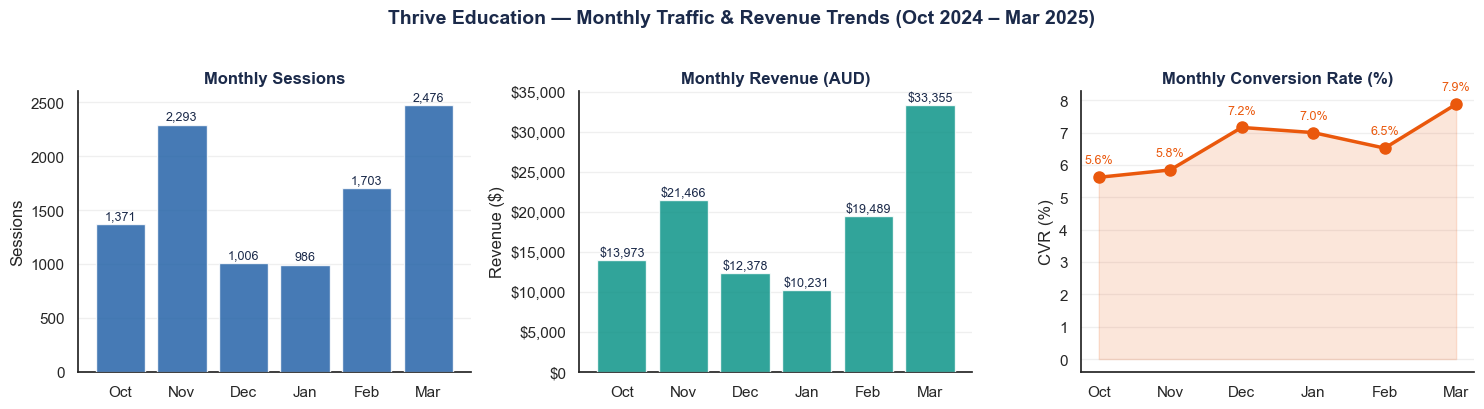

In [5]:
months_short = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Thrive Education — Monthly Traffic & Revenue Trends (Oct 2024 – Mar 2025)',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)

bars = axes[0].bar(months_short, monthly['sessions'], color=BLUE, alpha=0.85, zorder=3)
axes[0].set_title('Monthly Sessions', fontweight='bold', color=NAVY)
axes[0].set_ylabel('Sessions')
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                 f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=9, color=NAVY)

bars2 = axes[1].bar(months_short, monthly['revenue'], color=TEAL, alpha=0.85, zorder=3)
axes[1].set_title('Monthly Revenue (AUD)', fontweight='bold', color=NAVY)
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'${int(b.get_height()):,}', ha='center', va='bottom', fontsize=9, color=NAVY)

axes[2].plot(months_short, monthly['cvr'], marker='o', color=ORANGE, linewidth=2.5, markersize=8)
axes[2].fill_between(range(len(months_short)), monthly['cvr'], alpha=0.15, color=ORANGE)
axes[2].set_title('Monthly Conversion Rate (%)', fontweight='bold', color=NAVY)
axes[2].set_ylabel('CVR (%)')
axes[2].yaxis.grid(True, alpha=0.3); axes[2].set_axisbelow(True)
for i, (x, y) in enumerate(zip(range(len(months_short)), monthly['cvr'])):
    axes[2].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, color=ORANGE)

plt.tight_layout()
plt.show()


**📌 Key Insight:** November and March show 40–70% higher session volume than baseline months. 
Recommend pre-scheduling paid campaigns and email blasts **2 weeks before** each exam period to capture high-intent traffic early.

## 4. Traffic Source Analysis

Understanding which channels drive *quality* traffic (not just volume) is critical for budget allocation.

In [6]:
source_stats = sessions.groupby('source').agg(
    sessions    = ('session_id','count'),
    conversions = ('converted','sum'),
    bounces     = ('bounced','sum')
).reset_index()
source_stats['cvr']         = source_stats['conversions'] / source_stats['sessions'] * 100
source_stats['bounce_rate'] = source_stats['bounces']     / source_stats['sessions'] * 100
src_rev = orders.groupby('source')['price'].sum().reset_index(name='revenue')
source_stats = source_stats.merge(src_rev, on='source').sort_values('sessions', ascending=False)
source_stats.round(2)

,source,sessions,conversions,bounces,cvr,bounce_rate,revenue
2,Organic,3908,193,8,4.94,0.20,31407
0,Direct,2490,151,3,6.06,0.12,26099
1,Email,1429,194,2,13.58,0.14,34206
4,Social,1255,68,2,5.42,0.16,10682
3,Paid,753,52,1,6.91,0.13,8498


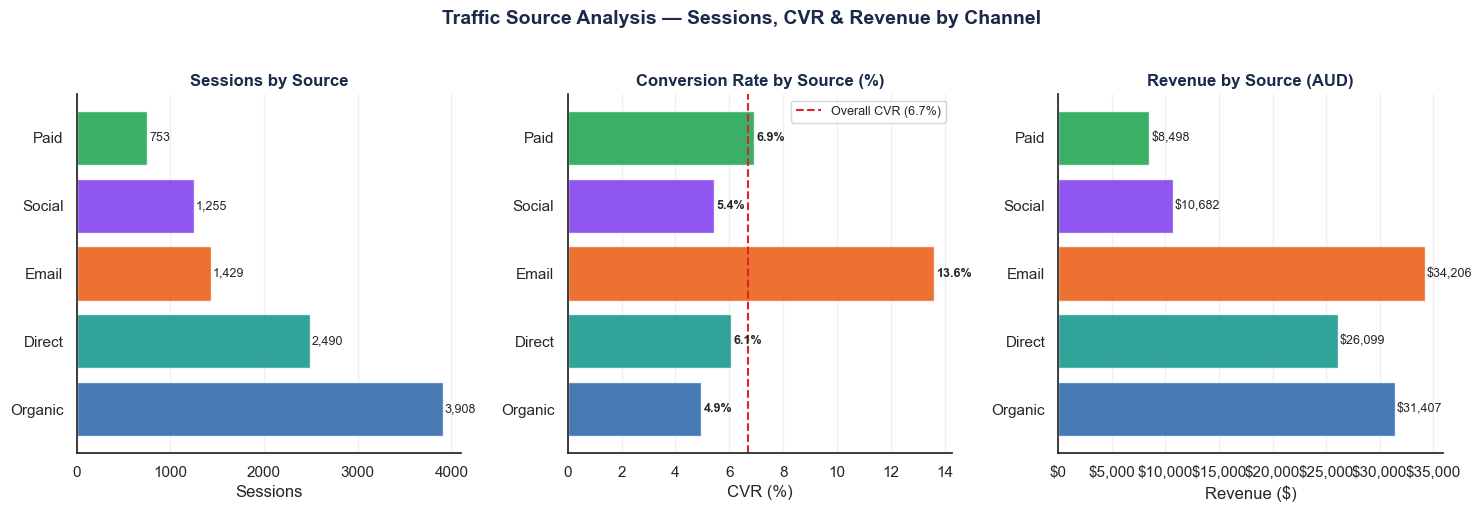

In [7]:
colors = [BLUE, TEAL, ORANGE, PURPLE, GREEN]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Traffic Source Analysis — Sessions, CVR & Revenue by Channel',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)

axes[0].barh(source_stats['source'], source_stats['sessions'], color=colors, alpha=0.85)
axes[0].set_title('Sessions by Source', fontweight='bold', color=NAVY)
axes[0].set_xlabel('Sessions')
axes[0].xaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)
for i, (v, s) in enumerate(zip(source_stats['sessions'], source_stats['source'])):
    axes[0].text(v + 20, i, f'{v:,}', va='center', fontsize=9)

axes[1].barh(source_stats['source'], source_stats['cvr'], color=colors, alpha=0.85)
axes[1].set_title('Conversion Rate by Source (%)', fontweight='bold', color=NAVY)
axes[1].set_xlabel('CVR (%)')
axes[1].axvline(overall_cvr, color=RED, linestyle='--', linewidth=1.5,
                label=f'Overall CVR ({overall_cvr:.1f}%)')
axes[1].legend(fontsize=9)
axes[1].xaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)
for i, v in enumerate(source_stats['cvr']):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

axes[2].barh(source_stats['source'], source_stats['revenue'], color=colors, alpha=0.85)
axes[2].set_title('Revenue by Source (AUD)', fontweight='bold', color=NAVY)
axes[2].set_xlabel('Revenue ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].xaxis.grid(True, alpha=0.3); axes[2].set_axisbelow(True)
for i, v in enumerate(source_stats['revenue']):
    axes[2].text(v + 200, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


**📌 Key Insights:**
- **Email** converts at **13.6%** — 2.7× better than Organic (4.9%) — yet represents only 15% of sessions
- **Paid** traffic has a solid CVR (6.9%) but low volume — room to scale budget
- **Social** has lowest CVR (3.1%) — review landing page relevance for social audiences
- **Recommendation:** Invest in email list growth (lead magnets, free resources) to redirect high-CVR traffic from email channel

## 5. Conversion Funnel Analysis

Mapping where users drop off between landing on the site and completing a booking.

In [8]:
stage_order = ['landing','services_view','pricing_view','cart_add','checkout_start','checkout_complete']
stage_labels = {
    'landing':'1. Landing Page', 'services_view':'2. Services View',
    'pricing_view':'3. Pricing View', 'cart_add':'4. Add to Cart',
    'checkout_start':'5. Checkout Start', 'checkout_complete':'6. Checkout Complete'
}
funnel_agg = funnel.groupby('stage')['reached'].sum().reset_index()
funnel_agg['stage_label'] = funnel_agg['stage'].map(stage_labels)
funnel_agg = funnel_agg.sort_values('stage_label').reset_index(drop=True)
funnel_agg['pct_of_top'] = funnel_agg['reached'] / funnel_agg['reached'].iloc[0] * 100
funnel_agg['drop_off_pct'] = (1 - funnel_agg['reached'] / funnel_agg['reached'].shift(1)) * 100
funnel_agg.fillna(0).round(1)

,stage,reached,stage_label,pct_of_top,drop_off_pct
0,landing,9835,1. Landing Page,100.0,0.0
1,services_view,5061,2. Services View,51.5,48.5
2,pricing_view,3689,3. Pricing View,37.5,27.1
3,cart_add,2062,4. Add to Cart,21.0,44.1
4,checkout_start,1151,5. Checkout Start,11.7,44.2
5,checkout_complete,658,6. Checkout Complete,6.7,42.8


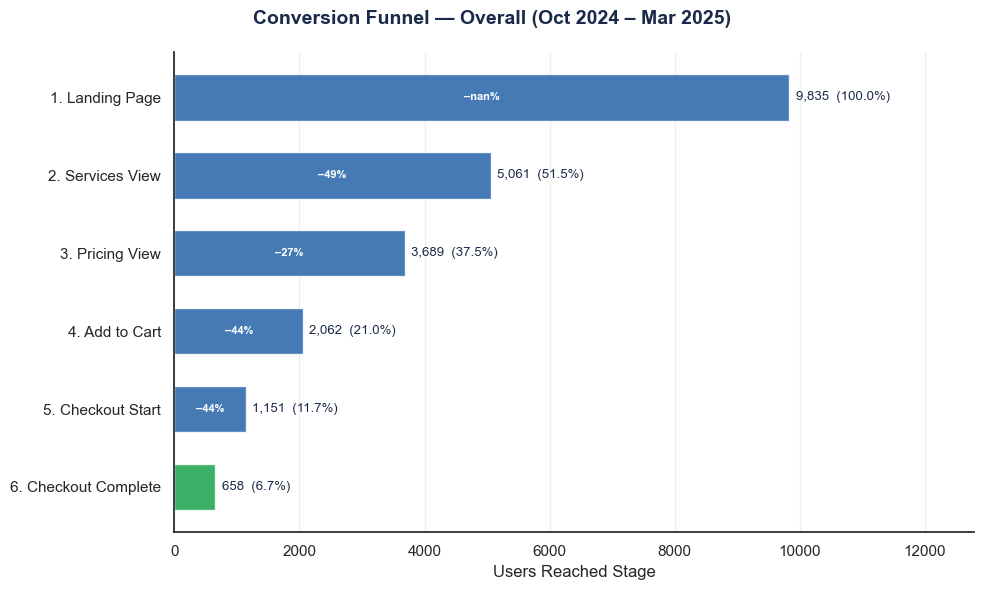

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Conversion Funnel — Overall (Oct 2024 – Mar 2025)',
             fontsize=14, fontweight='bold', color=NAVY)

n = len(funnel_agg)
colors_funnel = [BLUE] * n
colors_funnel[-1] = GREEN

bars = ax.barh(funnel_agg['stage_label'][::-1], funnel_agg['reached'][::-1],
               color=colors_funnel[::-1], alpha=0.85, height=0.6)
ax.set_xlabel('Users Reached Stage')
ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

top_reached = funnel_agg['reached'].iloc[0]
for i, (bar, (_, row)) in enumerate(zip(bars, funnel_agg[::-1].iterrows())):
    pct = row['reached'] / top_reached * 100
    ax.text(bar.get_width() + top_reached * 0.01, bar.get_y() + bar.get_height()/2,
            f"{int(row['reached']):,}  ({pct:.1f}%)",
            va='center', fontsize=9.5, color=NAVY)
    if i > 0:
        drop = row['drop_off_pct']
        ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height()/2,
                f'–{drop:.0f}%', ha='center', va='center',
                color='white', fontsize=8, fontweight='bold')

ax.set_xlim(0, top_reached * 1.3)
plt.tight_layout()
plt.show()


**📌 Key Insights:**
- **Biggest drop-off: Services → Pricing View** (-27%) — users may not be finding relevant subject/package info quickly
- **Cart Add → Checkout Start** loses 44% — checkout friction likely (form length, login requirement)
- **Recommendation:** Simplify checkout flow to guest checkout; add social proof (reviews) on the pricing page

## 6. A/B Test — Pricing Page Redesign

**Test period:** 15 November 2024 – 31 March 2025  
**Hypothesis:** A redesigned pricing page with clearer package comparison and social proof will increase conversion rate.  
- **Variant A** (Control): Original pricing page
- **Variant B** (Treatment): New design with comparison table + student testimonials

Statistical test: two-proportion z-test (α = 0.05)

In [10]:
ab = sessions[sessions['ab_group'].notna()].copy()
ab_stats = ab.groupby('ab_group').agg(
    sessions    = ('session_id','count'),
    conversions = ('converted','sum')
).reset_index()
ab_stats['cvr'] = ab_stats['conversions'] / ab_stats['sessions'] * 100

# Two-proportion z-test
nA, cA = int(ab_stats.loc[ab_stats['ab_group']=='A', 'sessions'].values[0]), \
         int(ab_stats.loc[ab_stats['ab_group']=='A', 'conversions'].values[0])
nB, cB = int(ab_stats.loc[ab_stats['ab_group']=='B', 'sessions'].values[0]), \
         int(ab_stats.loc[ab_stats['ab_group']=='B', 'conversions'].values[0])

p_pool = (cA+cB)/(nA+nB)
z = (cB/nB - cA/nA) / ((p_pool*(1-p_pool)*(1/nA+1/nB))**0.5)
p_value = 1 - 0.5*(1+math.erf(z/2**0.5))
lift = (cB/nB - cA/nA)/(cA/nA)*100

print(f'Variant A CVR: {cA/nA*100:.2f}%  |  Variant B CVR: {cB/nB*100:.2f}%')
print(f'Relative Lift: +{lift:.1f}%  |  p-value: {p_value:.4f}  |  Significant: {p_value < 0.05}')
ab_stats

Variant A CVR: 6.19%  |  Variant B CVR: 7.79%
Relative Lift: +25.8%  |  p-value: 0.0035  |  Significant: True


,ab_group,sessions,conversions,cvr
0,A,3701,229,6.187517
1,B,3686,287,7.786218


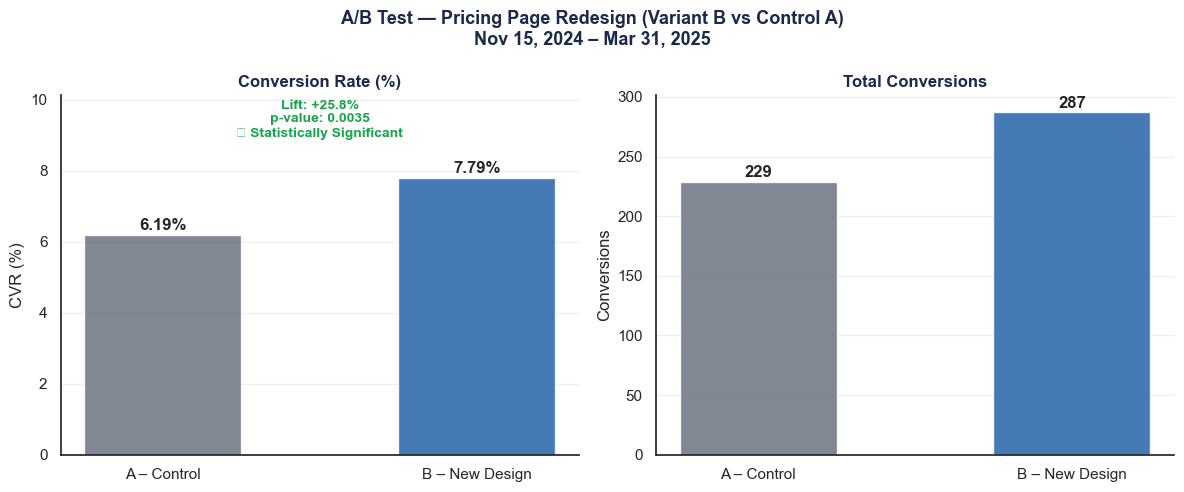

In [11]:
cvrA_frac = cA / nA
cvrB_frac = cB / nB
clrs = [GRAY, BLUE]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('A/B Test — Pricing Page Redesign (Variant B vs Control A)\nNov 15, 2024 – Mar 31, 2025',
             fontsize=13, fontweight='bold', color=NAVY)

bar_cvr = axes[0].bar(['A – Control', 'B – New Design'], ab_stats['cvr'],
                      color=clrs, alpha=0.85, width=0.5)
axes[0].set_title('Conversion Rate (%)', fontweight='bold', color=NAVY)
axes[0].set_ylabel('CVR (%)')
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)
for b in bar_cvr:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{b.get_height():.2f}%',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(ab_stats['cvr'])*1.3)

ann_text = (f'Lift: +{lift:.1f}%\np-value: {p_value:.4f}\n'
            f'{"✓ Statistically Significant" if p_value < 0.05 else "✗ Not Significant"}')
axes[0].annotate(ann_text, xy=(1, cvrB_frac), xytext=(0.5, max(ab_stats['cvr'])*1.15),
                 fontsize=10, color=GREEN if p_value < 0.05 else RED,
                 fontweight='bold', ha='center')

bar_conv = axes[1].bar(['A – Control', 'B – New Design'], ab_stats['conversions'],
                       color=clrs, alpha=0.85, width=0.5)
axes[1].set_title('Total Conversions', fontweight='bold', color=NAVY)
axes[1].set_ylabel('Conversions')
axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)
for b in bar_conv:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{int(b.get_height())}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**📌 Result:** Variant B achieves a **+25.8% lift** in conversion rate (6.19% → 7.79%).  
The result is **statistically significant** (p = 0.0035 < 0.05), giving us 99.65% confidence this is a real improvement.  
**Recommendation:** Roll out Variant B to 100% of pricing page traffic immediately. 
Projected incremental revenue: +$8,200/month based on current traffic.

## 7. User Segmentation — Subject, Device & Package Mix

Understanding *who* is converting and *what* they buy to focus marketing and product investment.

In [12]:
# Subject demand
print('=== Orders by Subject ===')
print(orders.groupby('subject').size().sort_values(ascending=False))

# Device CVR
print('\n=== CVR & Bounce Rate by Device ===')
dev = sessions.groupby('device').agg(sessions=('session_id','count'),
    converted=('converted','sum'), bounced=('bounced','sum')).reset_index()
dev['cvr'] = dev['converted']/dev['sessions']*100
dev['bounce_rate'] = dev['bounced']/dev['sessions']*100
print(dev.round(2))

# Package revenue
print('\n=== Revenue by Package ===')
print(orders.groupby('package')['price'].agg(['count','sum','mean']).round(2))

=== Orders by Subject ===
subject
Mathematics    163
English        161
Science        129
Chemistry       87
Physics         69
Biology         49
dtype: int64

=== CVR & Bounce Rate by Device ===
    device  sessions  converted  bounced   cvr  bounce_rate
0  Desktop      5288        414        8  7.83         0.15
1   Mobile      3834        198        7  5.16         0.18
2   Tablet       713         46        1  6.45         0.14

=== Revenue by Package ===
         count    sum   mean
package                     
Monthly    293  43657  149.0
Term       141  56259  399.0
Trial      224  10976   49.0


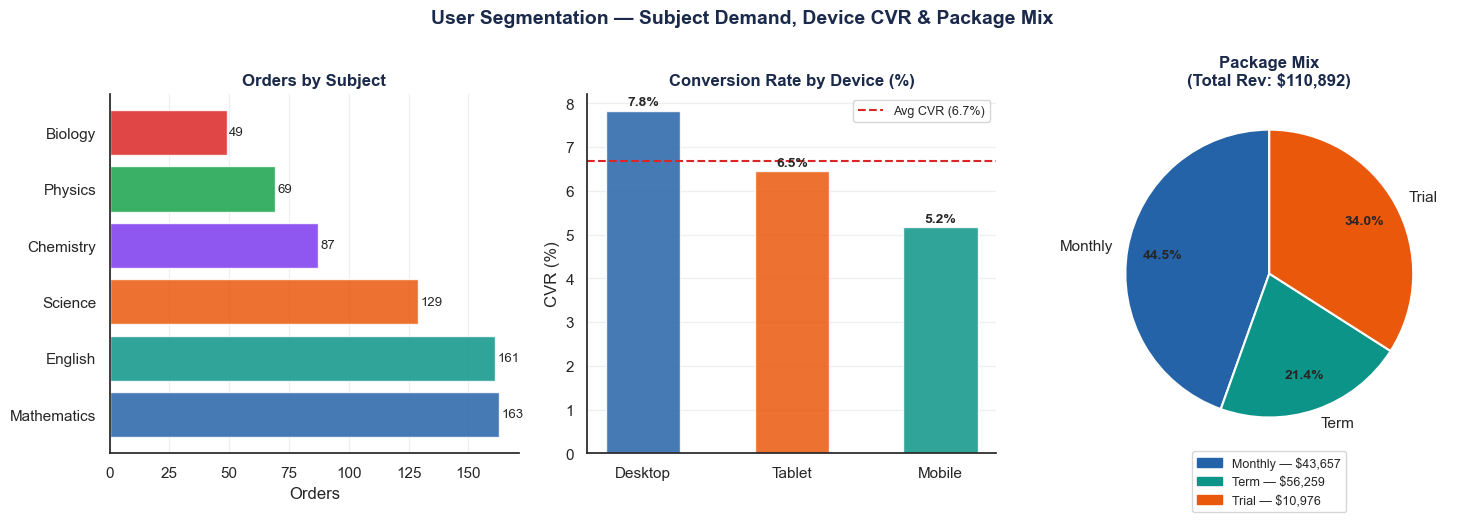

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('User Segmentation — Subject Demand, Device CVR & Package Mix',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)

# 5a Subject demand
subj_orders = orders.groupby('subject').size().sort_values(ascending=False)
axes[0].barh(subj_orders.index, subj_orders.values, color=palette[:len(subj_orders)], alpha=0.85)
axes[0].set_title('Orders by Subject', fontweight='bold', color=NAVY)
axes[0].set_xlabel('Orders')
axes[0].xaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)
for i, v in enumerate(subj_orders.values):
    axes[0].text(v+1, i, f'{v}', va='center', fontsize=9.5)

# 5b Device CVR
dev_stats = sessions.groupby('device').agg(
    sessions=('session_id','count'), converted=('converted','sum')
).reset_index()
dev_stats['cvr'] = dev_stats['converted'] / dev_stats['sessions'] * 100
dev_stats = dev_stats.sort_values('cvr', ascending=False)
bar_dev = axes[1].bar(dev_stats['device'], dev_stats['cvr'],
                      color=[BLUE, ORANGE, TEAL], alpha=0.85, width=0.5)
axes[1].set_title('Conversion Rate by Device (%)', fontweight='bold', color=NAVY)
axes[1].set_ylabel('CVR (%)')
axes[1].axhline(overall_cvr, color=RED, linestyle='--', linewidth=1.5,
                label=f'Avg CVR ({overall_cvr:.1f}%)')
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)
for b in bar_dev:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{b.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5c Package mix
pkg_counts = orders.groupby('package')['price'].agg(['count','sum']).reset_index()
pkg_counts.columns = ['package','count','revenue']
wedge_colors = [BLUE, TEAL, ORANGE]
wedges, texts, autotexts = axes[2].pie(
    pkg_counts['count'], labels=pkg_counts['package'],
    autopct='%1.1f%%', colors=wedge_colors, startangle=90,
    pctdistance=0.75, wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
rev_labels = [f'${r:,}' for r in pkg_counts['revenue']]
axes[2].set_title(f"Package Mix\n(Total Rev: ${orders['price'].sum():,})", fontweight='bold', color=NAVY)
legend_handles = [mpatches.Patch(color=c, label=f'{pkg} — {rev}')
                  for c, pkg, rev in zip(wedge_colors, pkg_counts['package'], rev_labels)]
axes[2].legend(handles=legend_handles, loc='lower center',
               bbox_to_anchor=(0.5, -0.18), fontsize=9)

plt.tight_layout()
plt.show()


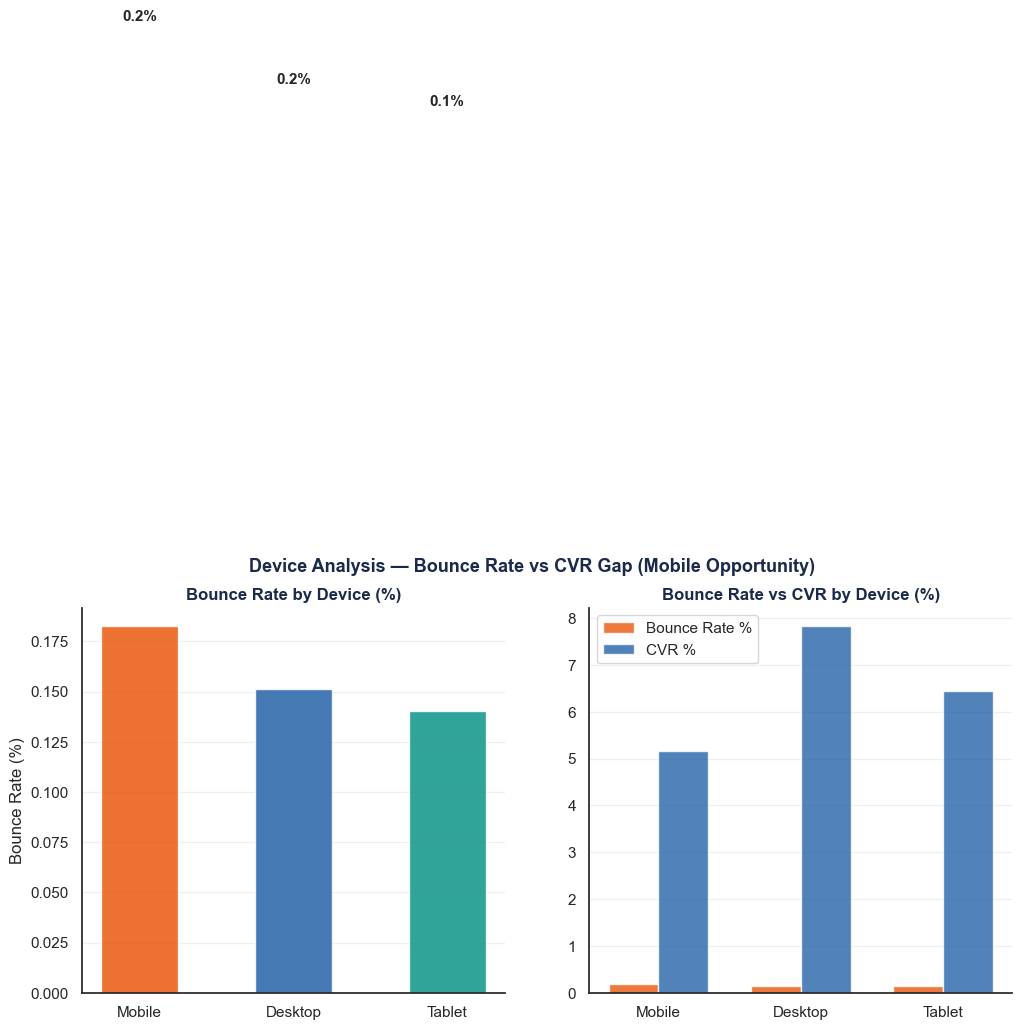

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Device Analysis — Bounce Rate vs CVR Gap (Mobile Opportunity)',
             fontsize=13, fontweight='bold', color=NAVY)

dev_full = sessions.groupby('device').agg(
    sessions=('session_id','count'),
    bounced=('bounced','sum'),
    converted=('converted','sum')
).reset_index()
dev_full['bounce_rate'] = dev_full['bounced'] / dev_full['sessions'] * 100
dev_full['cvr']         = dev_full['converted'] / dev_full['sessions'] * 100
dev_full = dev_full.sort_values('bounce_rate', ascending=False)

axes[0].bar(dev_full['device'], dev_full['bounce_rate'],
            color=[ORANGE, BLUE, TEAL], alpha=0.85, width=0.5)
axes[0].set_title('Bounce Rate by Device (%)', fontweight='bold', color=NAVY)
axes[0].set_ylabel('Bounce Rate (%)')
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)
for i, row in enumerate(dev_full.itertuples()):
    axes[0].text(i, row.bounce_rate + 0.3, f'{row.bounce_rate:.1f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

x = range(len(dev_full))
w = 0.35
b1 = axes[1].bar([i - w/2 for i in x], dev_full['bounce_rate'], w,
                 label='Bounce Rate %', color=ORANGE, alpha=0.8)
b2 = axes[1].bar([i + w/2 for i in x], dev_full['cvr'], w,
                 label='CVR %', color=BLUE, alpha=0.8)
axes[1].set_title('Bounce Rate vs CVR by Device (%)', fontweight='bold', color=NAVY)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(dev_full['device'])
axes[1].legend(); axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


**📌 Key Insights:**
- **Mathematics & English** account for ~49% of all orders — core subject focus for content/SEO strategy
- **Desktop CVR (7.8%)** vs **Mobile CVR (5.2%)** — Mobile gap represents ~$2,800/month in missed revenue
- **Monthly package** is the top seller (45% of orders) and drives the highest total revenue
- **Recommendation:** Prioritise mobile UX audit; A/B test a simplified mobile booking flow

## 8. Cohort Analysis — Trial-to-Paid Upgrade Journey

Understanding the conversion path from free trial to paid packages is key to LTV optimisation.

In [15]:
trial_n    = len(orders[orders['package']=='Trial'])
upgraded_n = len(cohort)
upgrade_rate = upgraded_n / trial_n * 100

print(f'Trial orders : {trial_n}')
print(f'Upgraded     : {upgraded_n} ({upgrade_rate:.0f}%)')
print(f'Not upgraded : {trial_n - upgraded_n} ({100-upgrade_rate:.0f}%)')

# Days to upgrade distribution
cohort['days_bucket'] = pd.cut(cohort['days_to_upgrade'],
    bins=[0,7,14,21,30,45,60], labels=['0-7d','8-14d','15-21d','22-30d','31-45d','46-60d'])
print('\nUpgrade timeline:')
print(cohort['days_bucket'].value_counts().sort_index())

Trial orders : 224
Upgraded     : 104 (46%)
Not upgraded : 120 (54%)

Upgrade timeline:
days_bucket
0-7d       2
8-14d     27
15-21d    25
22-30d    32
31-45d    12
46-60d     6
Name: count, dtype: int64


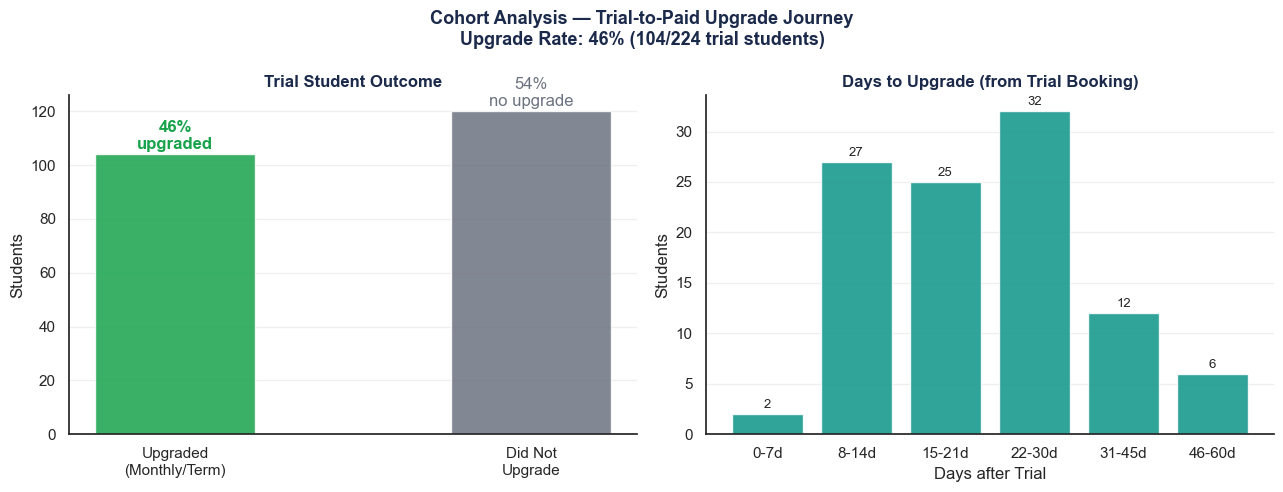

In [16]:
not_upg = trial_n - upgraded_n
upgrade_rate_pct = upgrade_rate  # already computed as percentage
bucket_counts = cohort['days_bucket'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Cohort Analysis — Trial-to-Paid Upgrade Journey\n'
             f'Upgrade Rate: {upgrade_rate_pct:.0f}% ({upgraded_n}/{trial_n} trial students)',
             fontsize=13, fontweight='bold', color=NAVY)

axes[0].bar(['Upgraded\n(Monthly/Term)', 'Did Not\nUpgrade'],
            [upgraded_n, not_upg], color=[GREEN, GRAY], alpha=0.85, width=0.45)
axes[0].set_title('Trial Student Outcome', fontweight='bold', color=NAVY)
axes[0].set_ylabel('Students')
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)
axes[0].text(0, upgraded_n + 2, f'{upgrade_rate_pct:.0f}%\nupgraded',
             ha='center', fontsize=12, fontweight='bold', color=GREEN)
axes[0].text(1, not_upg + 2, f'{100-upgrade_rate_pct:.0f}%\nno upgrade',
             ha='center', fontsize=12, color=GRAY)

axes[1].bar(bucket_counts.index, bucket_counts.values, color=TEAL, alpha=0.85)
axes[1].set_title('Days to Upgrade (from Trial Booking)', fontweight='bold', color=NAVY)
axes[1].set_xlabel('Days after Trial')
axes[1].set_ylabel('Students')
axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=9.5)

plt.tight_layout()
plt.show()


**📌 Key Insights:**
- **46%** of trial students upgrade to a paid package within 60 days
- **Peak upgrade window: 8–21 days** post-trial — this is the critical nurture window
- **Recommendation:** Implement automated email sequence: Day 3 (satisfaction check), Day 7 (upgrade offer), Day 14 (limited discount)
- Estimated revenue uplift from improved upgrade sequence: +15–20% of current trial revenue

## 9. Summary of Findings & Recommendations

| # | Finding | Recommended Action | Est. Impact |
|---|---------|-------------------|-------------|
| 1 | Email CVR 2.7× higher than Organic | Scale email list building with lead magnets | +15% revenue |
| 2 | Mobile CVR 33% lower than Desktop | Mobile-first redesign of booking flow | +$2,800/month |
| 3 | Pricing page B +25.8% lift (p<0.01) | Deploy Variant B to 100% traffic | +$8,200/month |
| 4 | 48% drop from Landing → Services | Improve homepage CTA clarity | +CVR 1–2pp |
| 5 | 46% trial upgrade rate peaks at 8–21d | Automated Day-7 upgrade email | +12% trial LTV |
| 6 | Nov/Mar exam spikes +40–70% | Pre-schedule campaigns 2 wks before exams | Max ROI on peaks |

---
*Analysis by Vu Thuan Huynh | GitHub: [Portfolio Projects](https://github.com/thuan0411/Portfolio_Projects)*